In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Load engineered dataset
df = pd.read_csv('/content/engineered_churn_data.csv')

print("Shape:", df.shape)
df.head()

Shape: (7043, 27)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,CLV,AvgMonthlySpend,ServiceCount,ContractRiskScore,ElectronicCheckFlag,TenureGroup,HighSpendFlag
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,29.85,0,29.85,29.850000,1,3,1,New,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,56.95,1889.50,0,1936.30,55.573529,3,2,0,Mature,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,1,107.70,54.075000,3,3,0,New,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,42.30,1840.75,0,1903.50,40.905556,3,2,0,Mature,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,1,141.40,75.825000,1,3,1,New,1


Overall Churn Rate: 26.54%


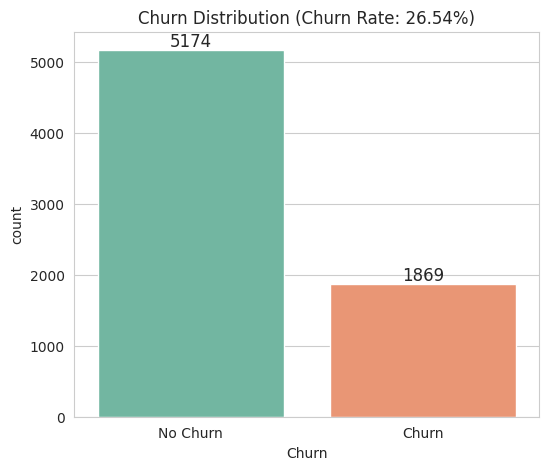

In [2]:
# Overall churn rate
churn_rate = df['Churn'].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")

# Visualize
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title(f'Churn Distribution (Churn Rate: {churn_rate:.2f}%)')
plt.xticks([0, 1], ['No Churn', 'Churn'])

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

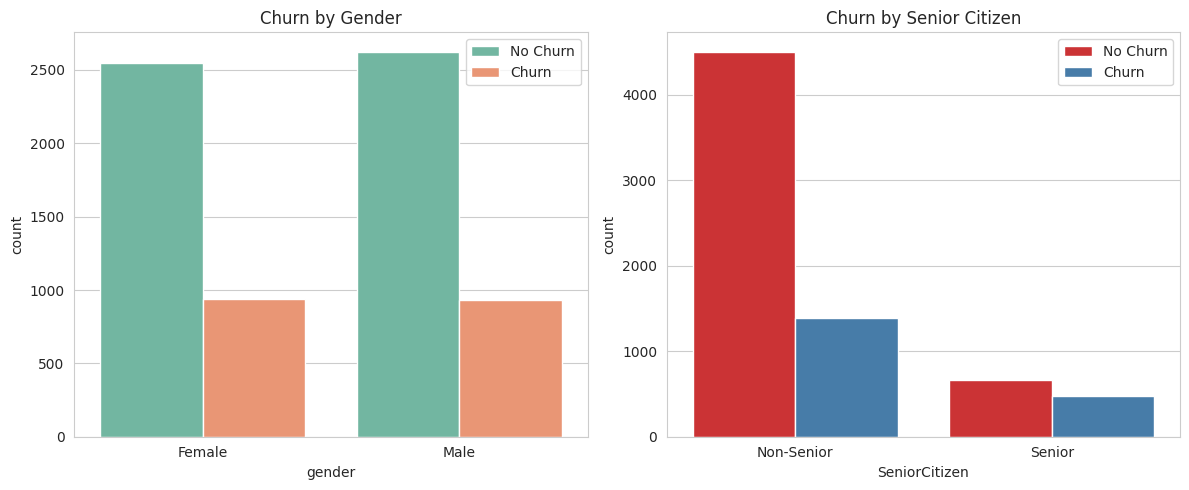

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender vs Churn
sns.countplot(x='gender', hue='Churn', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Gender')
axes[0].legend(['No Churn', 'Churn'])

# Senior Citizen vs Churn
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Churn by Senior Citizen')
axes[1].set_xticklabels(['Non-Senior', 'Senior'])
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

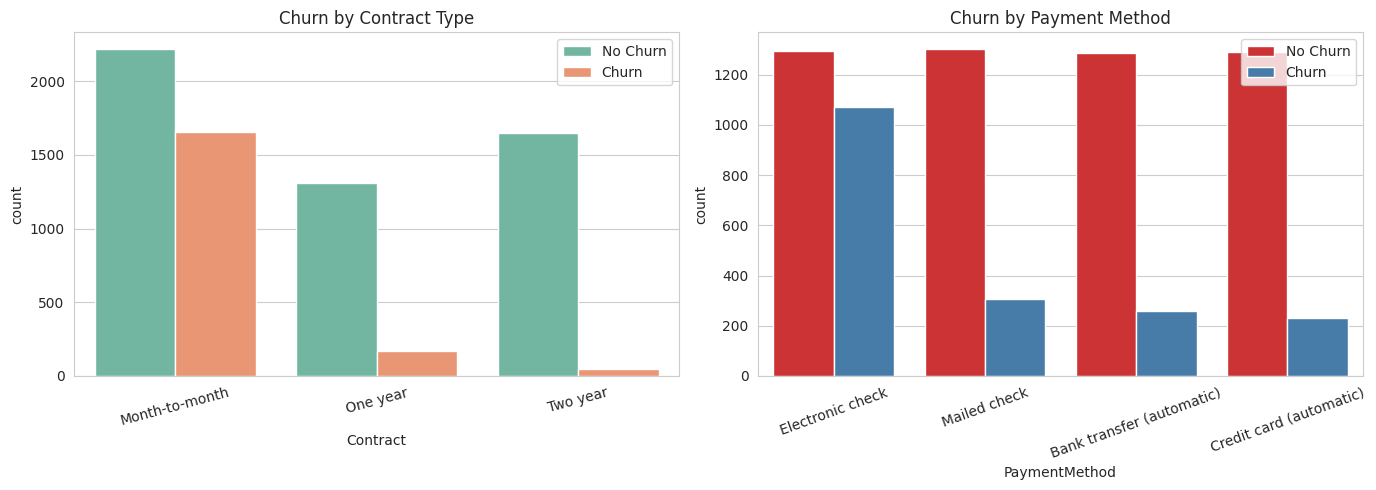

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract Type vs Churn
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Contract Type')
axes[0].legend(['No Churn', 'Churn'])
axes[0].tick_params(axis='x', rotation=15)

# Payment Method vs Churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Churn by Payment Method')
axes[1].legend(['No Churn', 'Churn'])
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

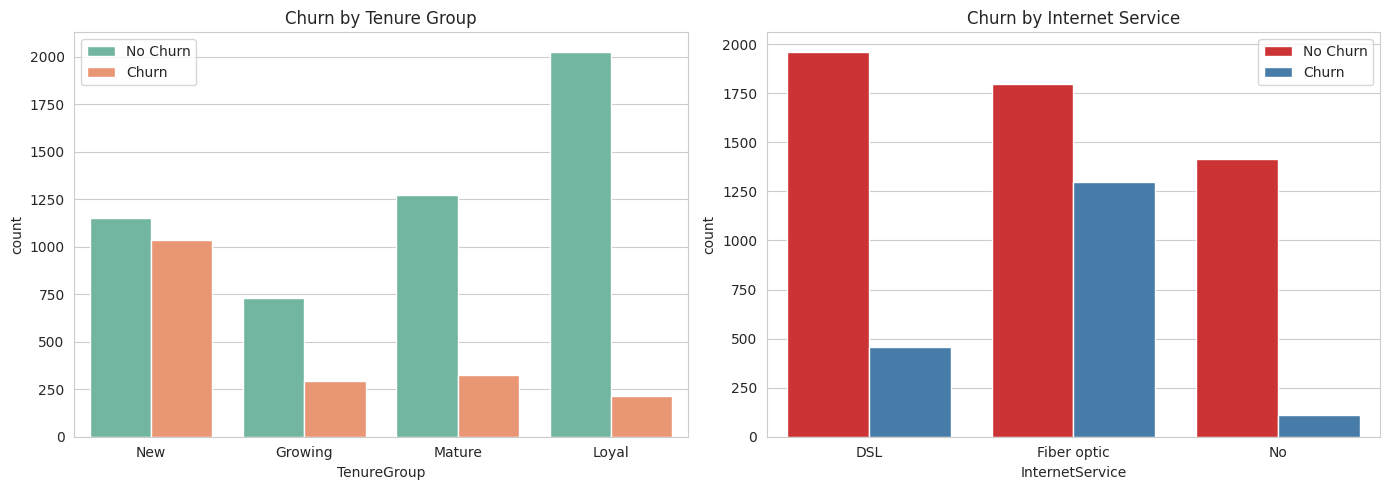

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure Group vs Churn
order = ['New', 'Growing', 'Mature', 'Loyal']
sns.countplot(x='TenureGroup', hue='Churn', data=df,
              palette='Set2', order=order, ax=axes[0])
axes[0].set_title('Churn by Tenure Group')
axes[0].legend(['No Churn', 'Churn'])

# Internet Service vs Churn
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette='Set1', ax=axes[1])
axes[1].set_title('Churn by Internet Service')
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

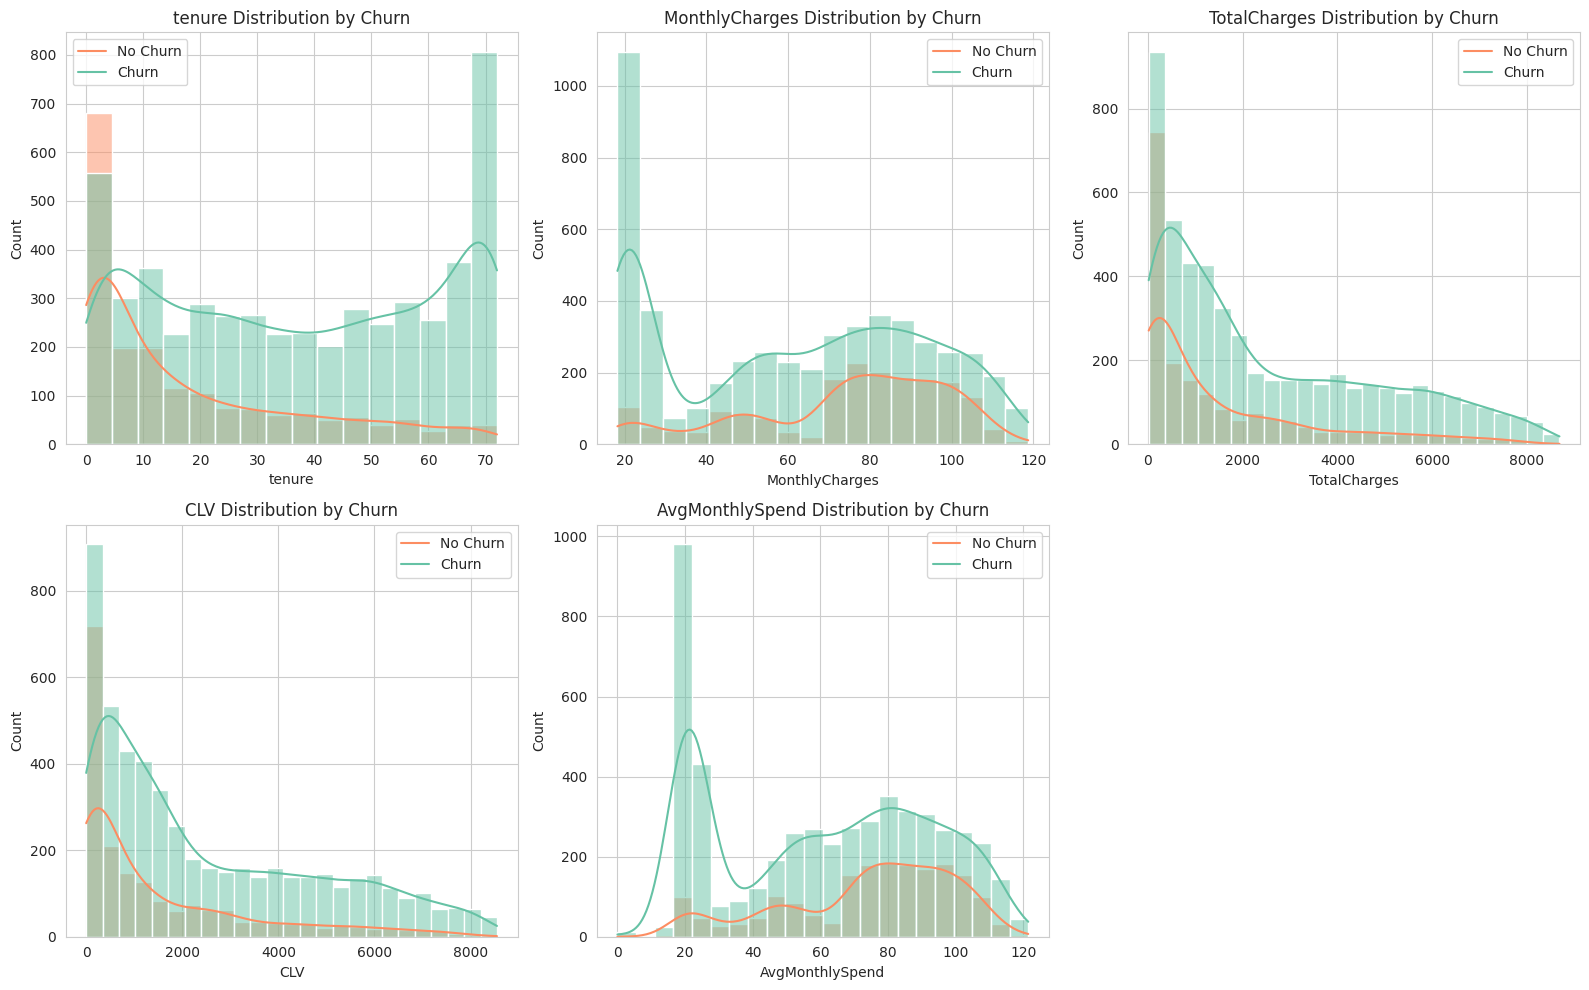

In [6]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'CLV', 'AvgMonthlySpend']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn',
                 kde=True, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Churn')
    axes[i].legend(['No Churn', 'Churn'])

# Hide last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

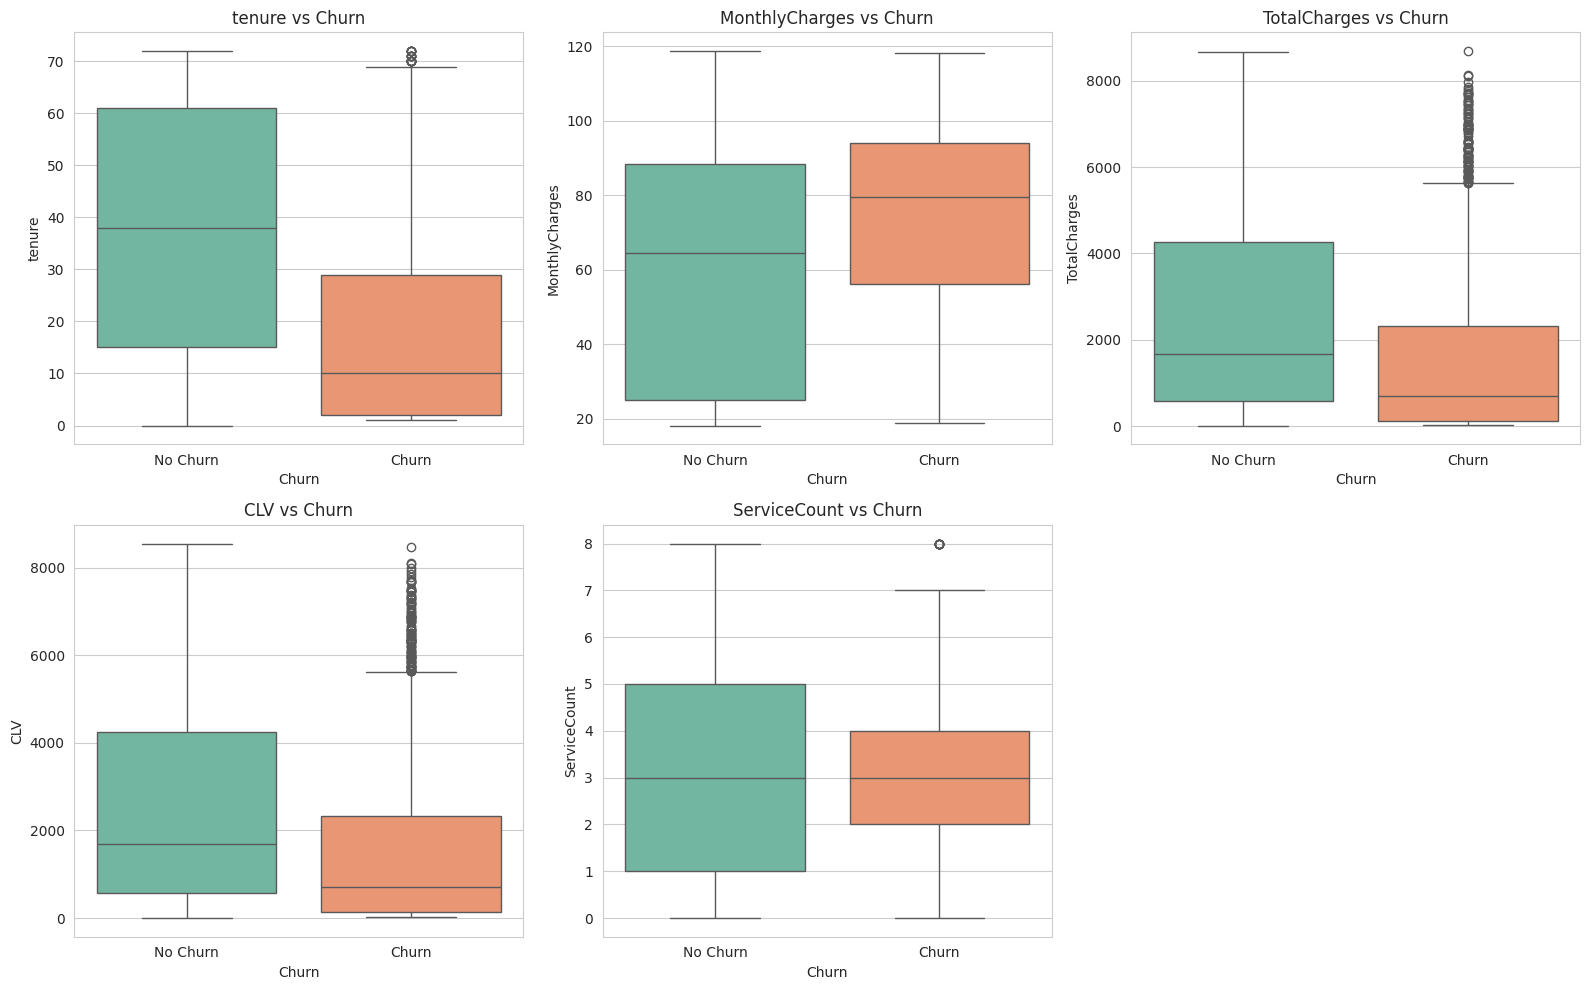

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'CLV', 'ServiceCount']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xticklabels(['No Churn', 'Churn'])

# Hide last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

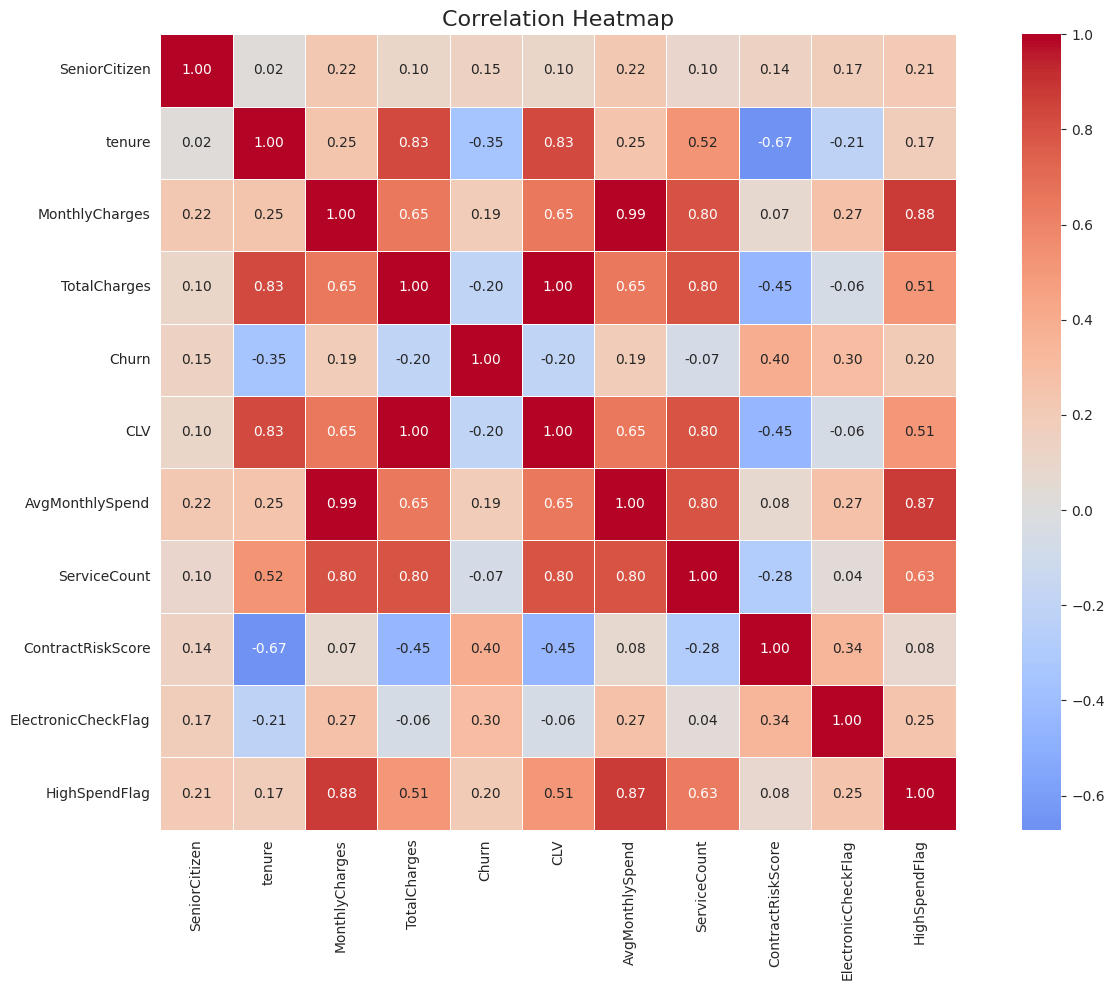

In [8]:
# Select numerical columns only
num_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(14, 10))
corr = num_df.corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

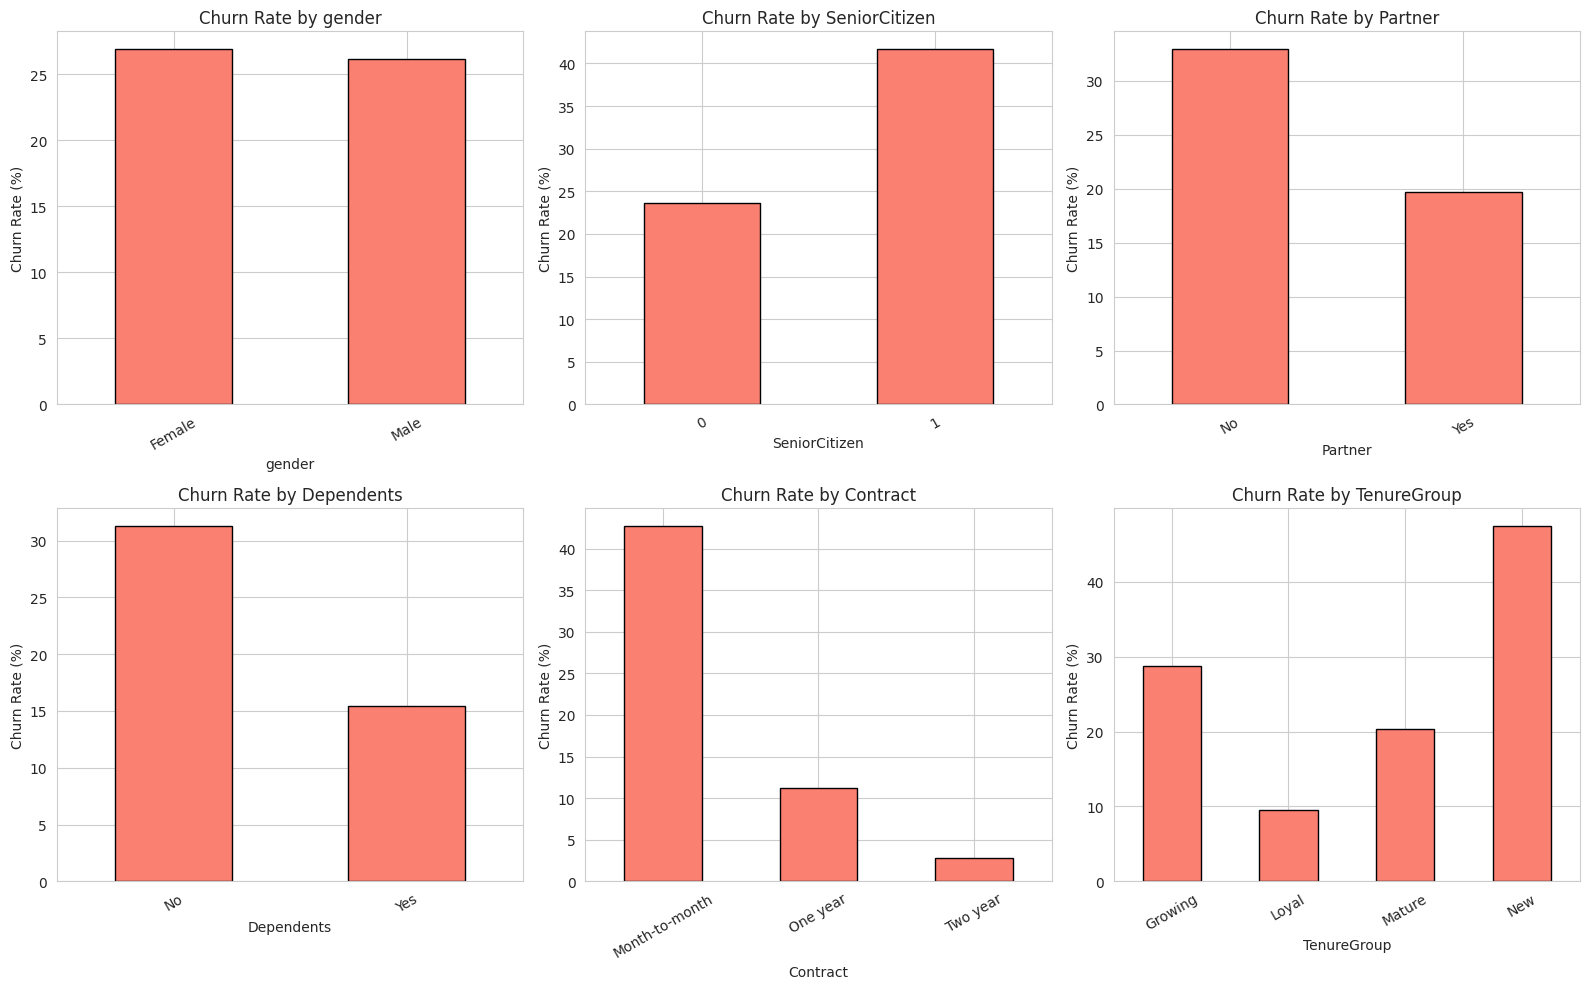

In [9]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'Contract', 'TenureGroup']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[i],
                    color='salmon', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

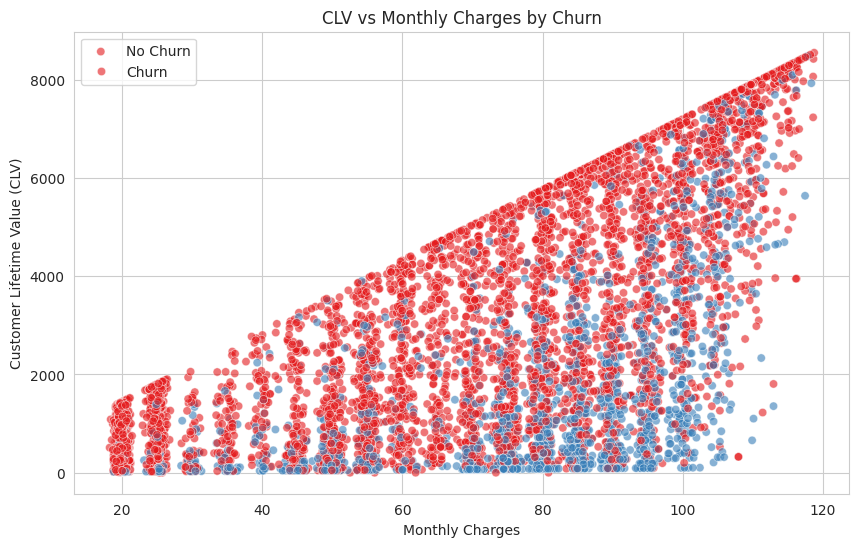

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='MonthlyCharges',
    y='CLV',
    hue='Churn',
    data=df,
    palette='Set1',
    alpha=0.6
)

plt.title('CLV vs Monthly Charges by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Lifetime Value (CLV)')
plt.legend(['No Churn', 'Churn'])
plt.show()

In [11]:
print("=" * 50)
print("         EDA KEY INSIGHTS SUMMARY")
print("=" * 50)

print(f"\n✅ Overall Churn Rate     : {df['Churn'].mean()*100:.2f}%")
print(f"✅ Avg Tenure (Churned)   : {df[df['Churn']==1]['tenure'].mean():.1f} months")
print(f"✅ Avg Tenure (Retained)  : {df[df['Churn']==0]['tenure'].mean():.1f} months")
print(f"✅ Avg CLV (Churned)      : ${df[df['Churn']==1]['CLV'].mean():.2f}")
print(f"✅ Avg CLV (Retained)     : ${df[df['Churn']==0]['CLV'].mean():.2f}")
print(f"✅ Senior Citizen Churn   : {df[df['SeniorCitizen']==1]['Churn'].mean()*100:.2f}%")
print(f"✅ Month-to-Month Churn   : {df[df['Contract']=='Month-to-month']['Churn'].mean()*100:.2f}%")
print(f"✅ Two Year Contract Churn: {df[df['Contract']=='Two year']['Churn'].mean()*100:.2f}%")
print("=" * 50)

         EDA KEY INSIGHTS SUMMARY

✅ Overall Churn Rate     : 26.54%
✅ Avg Tenure (Churned)   : 18.0 months
✅ Avg Tenure (Retained)  : 37.6 months
✅ Avg CLV (Churned)      : $1531.61
✅ Avg CLV (Retained)     : $2549.77
✅ Senior Citizen Churn   : 41.68%
✅ Month-to-Month Churn   : 42.71%
✅ Two Year Contract Churn: 2.83%


In [12]:
# Save the dataframe (no changes, just confirm)
df.to_csv('engineered_churn_data.csv', index=False)
print("✅ EDA Complete — Dataset ready for Modeling!")

✅ EDA Complete — Dataset ready for Modeling!
